In [73]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from google.colab import drive

In [74]:
# Load dataset
drive.mount("/content/drive")
df = pd.read_excel("/content/drive/MyDrive/Folds5x2_pp.xlsx")
dataset = pd.read_excel('/content/drive/MyDrive/Folds5x2_pp.xlsx')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


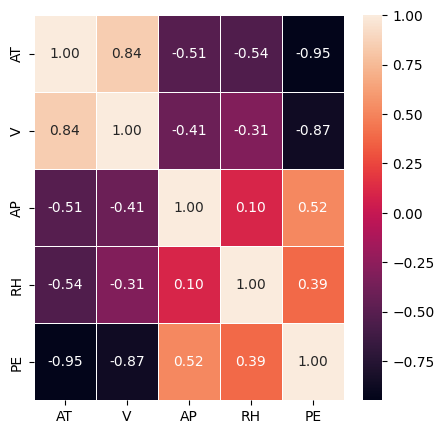

In [75]:
# correlation map
f,ax = plt.subplots(figsize=(5,5))
sns.heatmap(dataset.corr(), annot=True, linewidths=.5, fmt='.2f', ax=ax)
plt.show()

In [76]:
#show the number of cells in the dataframe
print("dataset size: ", df.size)

#show the number of records (rows) in the dataframe
print("number of records: ", len(df))

#show the number of features (coulmns) in the dataframe (exculde the response variable)
print("number of features: ", len(df.columns)-1)

dataset size:  47840
number of records:  9568
number of features:  4


In [77]:
#show each feature with its given description from UCI
Description = df.copy()
Description = Description.rename(columns = {'AT' : 'Temperature (T) in the range 1.81°C and 37.11°C',
                              'AP' : 'Ambient Pressure (AP) in the range 992.89-1033.30 milibar',
                              'V' : 'Exhaust Vacuum (V) in teh range 25.36-81.56 cm Hg',
                              'RH' : 'Relative Humidity (RH) in the range 25.56% to 100.16%',
                              'PE' : 'Net hourly electrical energy output (EP) 420.26-495.76 MW'})
Description.head(5)

,Temperature (T) in the range 1.81°C and 37.11°C,Exhaust Vacuum (V) in teh range 25.36-81.56 cm Hg,Ambient Pressure (AP) in the range 992.89-1033.30 milibar,Relative Humidity (RH) in the range 25.56% to 100.16%,Net hourly electrical energy output (EP) 420.26-495.76 MW
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### Metode Random Forest sebagai Acuan

## Splitting the dataset into the Training set and Test set

In [78]:
#split the dataset into two parts: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns= {'PE'}), df['PE'], test_size=0.2, random_state=42)

In [79]:
#Prepare a cross validation model with 10 folds
from sklearn.model_selection import KFold
Cross_Validation = KFold(n_splits = 10, shuffle=True, random_state = 42)

In [80]:
import time
RF_implementation_start_time = time.perf_counter()    #start the implementation time counter

### Mengevaluasi pengaruh jumlah pohon pada waktu fitting dan performa model.



In [81]:
# try different values of N_estimators
from sklearn.model_selection import cross_val_score # Import cross_val_score

N_estimators = [] # Menyimpan jumlah pohon yang diuji
N_estimators_fitting_time = [] # Menyimpan waktu fitting untuk setiap jumlah pohon
N_estimators_performance = [] # Menyimpan performa untuk setiap jumlah pohon

# Evaluasi dengan berbagai jumlah estimators (1 hingga 25 pohon)
for i in range(1, 25):
  RF_i = RandomForestRegressor(n_estimators = i)
  fitting_time_start_i = time.perf_counter()
  RF_Scores_i = cross_val_score(RF_i, X_train, y_train, cv=Cross_Validation)
  fitting_time_end_i = time.perf_counter()

  fitting_time_i = fitting_time_end_i - fitting_time_start_i
  performance_i = RF_Scores_i.mean()

  N_estimators.append(i)
  N_estimators_fitting_time.append(fitting_time_i)
  N_estimators_performance.append(performance_i)


In [82]:
# Membuat DataFrame untuk hasil eksperimen
results = {
    'N_estimators': N_estimators,
    'Fitting Time (seconds)': N_estimators_fitting_time,
    'Performance (R²)': N_estimators_performance
}

results_df = pd.DataFrame(results)

# Menampilkan hasil
print(results_df)


    N_estimators  Fitting Time (seconds)  Performance (R²)
0              1                0.422042          0.917849
1              2                0.759062          0.938781
2              3                1.127244          0.946569
3              4                1.481147          0.948880
4              5                1.783378          0.950473
5              6                2.109576          0.952939
6              7                3.054954          0.954242
7              8                3.390744          0.955098
8              9                3.157690          0.954558
9             10                3.540743          0.956183
10            11                4.563231          0.956421
11            12                4.477314          0.956600
12            13                4.518120          0.956445
13            14                5.912780          0.957060
14            15                5.259202          0.957410
15            16                5.837226          0.9579

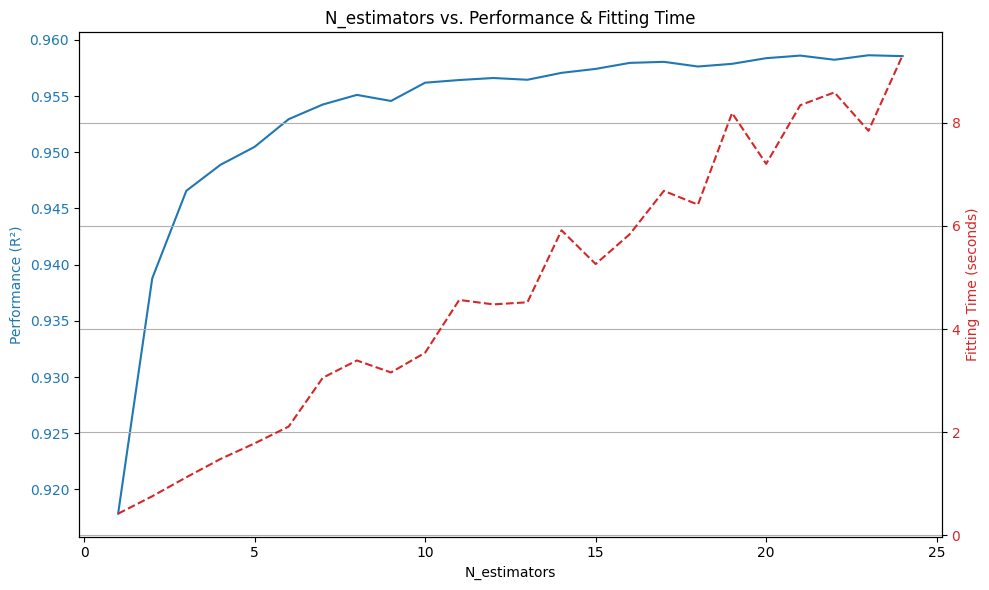

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot performa pada sumbu Y kiri
ax1.set_xlabel('N_estimators')
ax1.set_ylabel('Performance (R²)', color='tab:blue')
ax1.plot(N_estimators, N_estimators_performance, color='tab:blue', label='Performance')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Buat sumbu kedua untuk waktu fitting
ax2 = ax1.twinx()
ax2.set_ylabel('Fitting Time (seconds)', color='tab:red')
ax2.plot(N_estimators, N_estimators_fitting_time, color='tab:red', label='Fitting Time', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Menambahkan judul dan grid
plt.title('N_estimators vs. Performance & Fitting Time')
fig.tight_layout()  # Adjust layout to make room for labels
plt.grid(True)
plt.show()


### Menguji performa model dengan dua kriteria error yang berbeda (MSE vs. AE), dengan jumlah pohon tetap

In [84]:
RF_mae = RandomForestRegressor(n_estimators=8, criterion='absolute_error') # mengukur error absolut.

RF_mae_fitting_time_start = time.perf_counter()
RF_mae_scores = cross_val_score(RF_mae, X_train, y_train, cv=Cross_Validation)
RF_mae_fitting_time_end = time.perf_counter()
print('Random Forest regression with absolute_error criterion:')
print('Fitting time: ', RF_mae_fitting_time_end - RF_mae_fitting_time_start)
print('Performance: ', RF_mae_scores.mean())

RF_mse = RandomForestRegressor(n_estimators=8, criterion='squared_error') # mengukur Mean Squared Error (MSE).

RF_mse_fitting_time_start = time.perf_counter()
RF_mse_scores = cross_val_score(RF_mse, X_train, y_train, cv=Cross_Validation)
RF_mse_fitting_time_end = time.perf_counter()
print('Random Forest regression with squared_error criterion:') # Updated print statement
print('Fitting time: ',RF_mse_fitting_time_end - RF_mse_fitting_time_start)
print('Performance: ', RF_mse_scores.mean())

Random Forest regression with absolute_error criterion:
Fitting time:  40.0028602020011
Performance:  0.9542497671391962
Random Forest regression with squared_error criterion:
Fitting time:  2.769274693000625
Performance:  0.9542775360055881


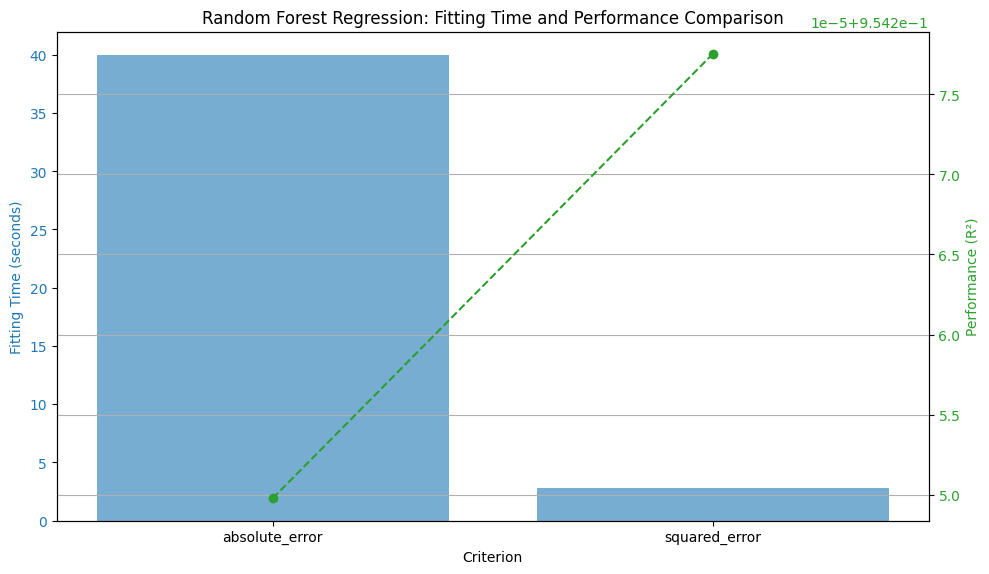

In [85]:
# Store the results of the criterion comparison
criterion_results = {
    'Criterion': ['absolute_error', 'squared_error'],
    'Fitting Time (seconds)': [RF_mae_fitting_time_end - RF_mae_fitting_time_start, RF_mse_fitting_time_end - RF_mse_fitting_time_start],
    'Performance (R²)': [RF_mae_scores.mean(), RF_mse_scores.mean()]
}

criterion_results_df = pd.DataFrame(criterion_results)

# Grafik perbandingan Fitting Time dan Performance
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot waktu fitting pada sumbu kiri
ax1.set_xlabel('Criterion')
ax1.set_ylabel('Fitting Time (seconds)', color='tab:blue')
# Use the new DataFrame for plotting criterion results
ax1.bar(criterion_results_df['Criterion'], criterion_results_df['Fitting Time (seconds)'], color='tab:blue', alpha=0.6, label='Fitting Time')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Buat sumbu kedua untuk Performance (R²)
ax2 = ax1.twinx()
ax2.set_ylabel('Performance (R²)', color='tab:green')
# Use the new DataFrame for plotting criterion results
ax2.plot(criterion_results_df['Criterion'], criterion_results_df['Performance (R²)'], color='tab:green', marker='o', label='Performance (R²)', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Menambahkan judul dan grid
plt.title('Random Forest Regression: Fitting Time and Performance Comparison')
fig.tight_layout()  # Adjust layout to make room for labels
plt.grid(True)

# Menampilkan grafik
plt.show()

### Model Random Forest Regression dengan menggunakan pengaturan max_features

In [86]:
# Pengaturan max_features="auto"
# 1. max_features="auto"
RF_auto = RandomForestRegressor(n_estimators=8, criterion='squared_error', max_features="sqrt")
RF_auto_fitting_time_start = time.perf_counter()
RF_auto_scores = cross_val_score(RF_auto, X_train, y_train, cv=Cross_Validation)
RF_auto_fitting_time_end = time.perf_counter()
RF_auto_fitting_time = RF_auto_fitting_time_end - RF_auto_fitting_time_start
RF_auto_performance = RF_auto_scores.mean()
print('Random Forest regression with max_features = sqrt:')
print('Fitting time: ', RF_auto_fitting_time)
print('Performance: ', RF_auto_performance)

# 2. max_features="sqrt"
# Setiap pohon hanya akan menggunakan akar kuadrat dari jumlah fitur.
RF_sqrt = RandomForestRegressor(n_estimators=8, criterion='squared_error', max_features="sqrt")
RF_sqrt_fitting_time_start = time.perf_counter()
RF_sqrt_scores = cross_val_score(RF_sqrt, X_train, y_train, cv=Cross_Validation)
RF_sqrt_fitting_time_end = time.perf_counter()
RF_sqrt_fitting_time = RF_sqrt_fitting_time_end - RF_sqrt_fitting_time_start
RF_sqrt_performance = RF_sqrt_scores.mean()
print('Random Forest regression with max_features = sqrt(n):')
print('Fitting time: ', RF_sqrt_fitting_time)
print('Performance: ', RF_sqrt_performance)


# 3. max_features="log2"
# Jumlah fitur yang digunakan diatur dengan menggunakan logaritma basis 2 dari jumlah fitur.
RF_log2 = RandomForestRegressor(n_estimators=8, criterion='squared_error', max_features="log2")
RF_log2_fitting_time_start = time.perf_counter()
RF_log2_scores = cross_val_score(RF_log2, X_train, y_train, cv=Cross_Validation)
RF_log2_fitting_time_end = time.perf_counter()
RF_log2_fitting_time = RF_log2_fitting_time_end - RF_log2_fitting_time_start
RF_log2_performance = RF_log2_scores.mean()
print('Random Forest regression with max_features = log2(n):')
print('Fitting time: ', RF_log2_fitting_time)
print('Performance: ', RF_log2_performance)

Random Forest regression with max_features = sqrt:
Fitting time:  1.6738499869989028
Performance:  0.9564673977845354
Random Forest regression with max_features = sqrt(n):
Fitting time:  1.6514635229996202
Performance:  0.9573884889781166
Random Forest regression with max_features = log2(n):
Fitting time:  1.6673218710002402
Performance:  0.9569841606280933


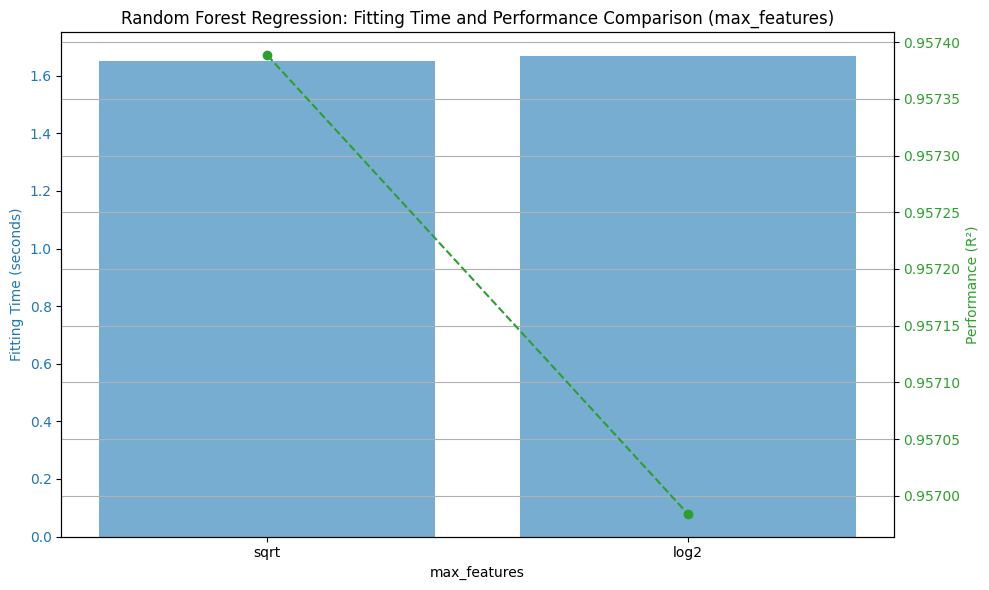

In [87]:
# Create a new DataFrame for max_features results
max_features_results = {
    'max_features': ['sqrt', 'log2'], # Include the actual max_features values tested
    'Fitting Time (seconds)': [RF_sqrt_fitting_time, RF_log2_fitting_time],
    'Performance (R²)': [RF_sqrt_performance, RF_log2_performance]
}

max_features_results_df = pd.DataFrame(max_features_results)

# Membuat grafik untuk perbandingan antara waktu fitting dan performa
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot waktu fitting
ax1.set_xlabel('max_features')
ax1.set_ylabel('Fitting Time (seconds)', color='tab:blue')

ax1.bar(max_features_results_df['max_features'], max_features_results_df['Fitting Time (seconds)'], color='tab:blue', alpha=0.6, label='Fitting Time')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Buat sumbu kedua untuk Performance (R²)
ax2 = ax1.twinx()
ax2.set_ylabel('Performance (R²)', color='tab:green')

ax2.plot(max_features_results_df['max_features'], max_features_results_df['Performance (R²)'], color='tab:green', marker='o', label='Performance (R²)', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Menambahkan judul dan grid
plt.title('Random Forest Regression: Fitting Time and Performance Comparison (max_features)')
fig.tight_layout()
plt.grid(True)

# Menampilkan grafik
plt.show()

### Evaluasi Random Forest Regressor pada dataset

In [88]:
# Evaluasi dengan N_estimators yang berbeda menggunakan cross-validation dan menyimpan hasil
RF_fitting_time_list = []
RF_performance_scores_list = []

# Iterasi untuk setiap fold dan nilai n_estimators
for i in range(1, 20):
    RF_Model = RandomForestRegressor(n_estimators=i, criterion='squared_error', max_features="sqrt")

    # Mulai waktu fitting
    RF_fitting_start_time = time.perf_counter()

    # Cross-validation untuk mengukur kinerja
    RF_performance_scores = cross_val_score(RF_Model, X_train, y_train, cv=Cross_Validation)

    # Akhir waktu fitting
    RF_fitting_end_time = time.perf_counter()

    # Simpan waktu fitting dan performa
    RF_fitting_time_list.append(RF_fitting_end_time - RF_fitting_start_time)
    RF_performance_scores_list.append(RF_performance_scores.mean())

# Menampilkan hasil secara lebih terstruktur
print("\nRandom Forest Regression Results: \n")
print(f"Performance Scores (Cross-validation scores per fold):")
print(f"{'Fold':<5}{'Performance (R²)'}")
for idx, score in enumerate(RF_performance_scores_list, 1):
    print(f"{idx:<5}{score:.4f}")

RF_average_performance = sum(RF_performance_scores_list) / len(RF_performance_scores_list)

# Menampilkan rata-rata performa dan waktu
print("\nAverage Performance (R²):")
print(f"Performance (R²): {RF_average_performance:.4f}")

RF_fitting_time = sum(RF_fitting_time_list)  # Total fitting time
print("\nTime Analysis:")
print(f"{'Metric':<20}{'Time (seconds)'}")
print(f"{'Fitting Time:':<20}{RF_fitting_time:.4f}")



Random Forest Regression Results: 

Performance Scores (Cross-validation scores per fold):
Fold Performance (R²)
1    0.9128
2    0.9381
3    0.9461
4    0.9499
5    0.9524
6    0.9551
7    0.9563
8    0.9578
9    0.9568
10   0.9582
11   0.9583
12   0.9587
13   0.9591
14   0.9595
15   0.9601
16   0.9600
17   0.9600
18   0.9603
19   0.9602

Average Performance (R²):
Performance (R²): 0.9537

Time Analysis:
Metric              Time (seconds)
Fitting Time:       42.6624


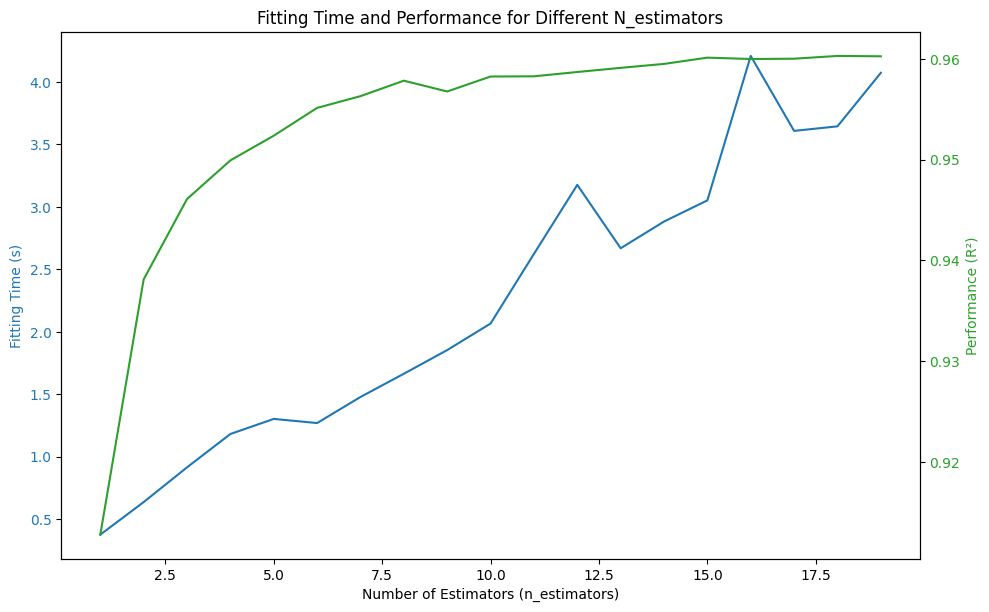

In [89]:
# Plotting grafik untuk waktu fitting dan performa
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Estimators (n_estimators)')
ax1.set_ylabel('Fitting Time (s)', color=color)
ax1.plot(range(1, 20), RF_fitting_time_list, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Performance (R²)', color=color)
ax2.plot(range(1, 20), RF_performance_scores_list, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Fitting Time and Performance for Different N_estimators")
plt.show()
